In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

gausman_2025 = pd.read_csv('../data/gausman_2025.csv')
gausman_2026 = pd.read_csv('../data/gausman_2026.csv')

print(f"Gausman 2025: {len(gausman_2025)} pitches")
print(f"Gausman 2026: {len(gausman_2026)} pitches")

Gausman 2025: 3038 pitches
Gausman 2026: 439 pitches


In [2]:
from pybaseball import statcast_pitcher

gausman_id = 592332

gausman_2022 = statcast_pitcher('2022-03-20', '2022-10-01', gausman_id)
gausman_2023 = statcast_pitcher('2023-03-20', '2023-10-01', gausman_id)
gausman_2024 = statcast_pitcher('2024-03-20', '2024-10-01', gausman_id)

print(f"Gausman 2022: {len(gausman_2022)} pitches")
print(f"Gausman 2023: {len(gausman_2023)} pitches")
print(f"Gausman 2024: {len(gausman_2024)} pitches")

Gathering Player Data
Gathering Player Data
Gathering Player Data
Gausman 2022: 2798 pitches
Gausman 2023: 3157 pitches
Gausman 2024: 3011 pitches


In [3]:
all_gausman = pd.concat([
    gausman_2022.assign(season=2022),
    gausman_2023.assign(season=2023),
    gausman_2024.assign(season=2024),
    gausman_2025.assign(season=2025),
    gausman_2026.assign(season=2026)
])

# Fastball velocity by season
fb_velo = all_gausman[all_gausman['pitch_type'] == 'FF'].groupby('season')['release_speed'].mean()

print("=== Gausman Fastball Velocity by Season ===")
for year, velo in fb_velo.items():
    age = year - 1991  # Gausman born 1991
    print(f"{year} (Age {age}): {velo:.1f} mph")

=== Gausman Fastball Velocity by Season ===
2022 (Age 31): 94.9 mph
2023 (Age 32): 94.7 mph
2024 (Age 33): 94.0 mph
2025 (Age 34): 94.5 mph
2026 (Age 35): 93.8 mph


In [4]:
print("=== Gausman Pitch Mix by Season ===\n")
for year in [2022, 2023, 2024, 2025, 2026]:
    season_data = all_gausman[all_gausman['season'] == year]
    mix = season_data['pitch_type'].value_counts(normalize=True) * 100
    print(f"--- {year} ---")
    print(mix.round(1))
    print()

=== Gausman Pitch Mix by Season ===

--- 2022 ---
pitch_type
FF    49.0
FS    35.5
SL    14.3
CH     1.3
Name: proportion, dtype: float64

--- 2023 ---
pitch_type
FF    50.9
FS    38.0
SL    10.2
ST     0.6
SI     0.2
Name: proportion, dtype: float64

--- 2024 ---
pitch_type
FF    51.8
FS    33.5
SL     8.4
SI     6.2
Name: proportion, dtype: float64

--- 2025 ---
pitch_type
FF    53.7
FS    37.4
SL     8.8
SI     0.1
Name: proportion, dtype: float64

--- 2026 ---
pitch_type
FF    50.8
FS    42.8
SL     6.4
Name: proportion, dtype: float64



Chart saved!


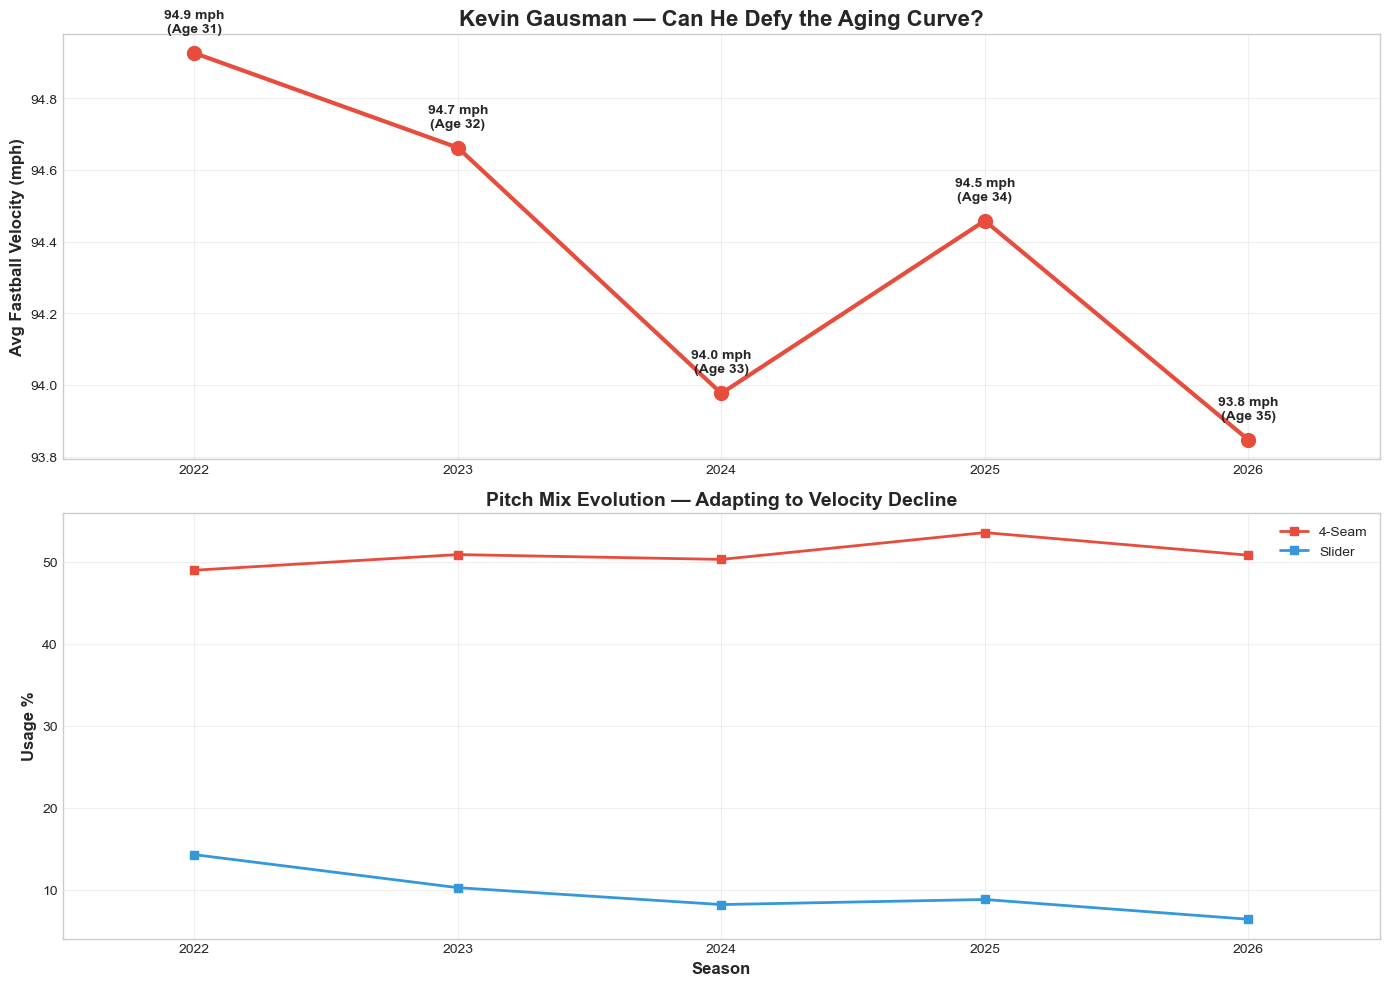

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

seasons = [2022, 2023, 2024, 2025, 2026]
ages = [31, 32, 33, 34, 35]

# Top: Fastball velocity trend
fb_velocities = [all_gausman[(all_gausman['season'] == y) & 
                 (all_gausman['pitch_type'] == 'FF')]['release_speed'].mean() 
                 for y in seasons]

ax1.plot(seasons, fb_velocities, color='#e74c3c', linewidth=3, 
         marker='o', markersize=10)

for i, (yr, velo, age) in enumerate(zip(seasons, fb_velocities, ages)):
    ax1.annotate(f'{velo:.1f} mph\n(Age {age})', xy=(yr, velo),
                 xytext=(0, 15), textcoords='offset points',
                 ha='center', fontsize=10, fontweight='bold')

ax1.set_ylabel('Avg Fastball Velocity (mph)', fontsize=12, fontweight='bold')
ax1.set_title("Kevin Gausman — Can He Defy the Aging Curve?",
              fontsize=16, fontweight='bold')
ax1.set_xlim(2021.5, 2026.5)
ax1.grid(True, alpha=0.3)

# Bottom: Pitch mix evolution
pitch_types_to_track = ['FF', 'SL', 'CH', 'ST', 'KC', 'SI', 'FC', 'CU']
pitch_colors = {'FF': '#e74c3c', 'SL': '#3498db', 'CH': '#2ecc71',
                'ST': '#9b59b6', 'KC': '#e67e22', 'SI': '#1abc9c',
                'FC': '#95a5a6', 'CU': '#f39c12'}
pitch_labels = {'FF': '4-Seam', 'SL': 'Slider', 'CH': 'Changeup',
                'ST': 'Sweeper', 'KC': 'K-Curve', 'SI': 'Sinker',
                'FC': 'Cutter', 'CU': 'Curveball'}

for pt in pitch_types_to_track:
    pcts = []
    valid_seasons = []
    for y in seasons:
        season_data = all_gausman[all_gausman['season'] == y]
        total = len(season_data)
        pt_count = len(season_data[season_data['pitch_type'] == pt])
        if total > 0:
            pct = pt_count / total * 100
            if pct > 2:
                pcts.append(pct)
                valid_seasons.append(y)
    if len(pcts) >= 2:
        ax2.plot(valid_seasons, pcts, linewidth=2, marker='s', markersize=6,
                 color=pitch_colors.get(pt, '#95a5a6'),
                 label=pitch_labels.get(pt, pt))

ax2.set_xlabel('Season', fontsize=12, fontweight='bold')
ax2.set_ylabel('Usage %', fontsize=12, fontweight='bold')
ax2.set_title("Pitch Mix Evolution — Adapting to Velocity Decline",
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.set_xlim(2021.5, 2026.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/07_gausman_aging_curve.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

Chart saved!


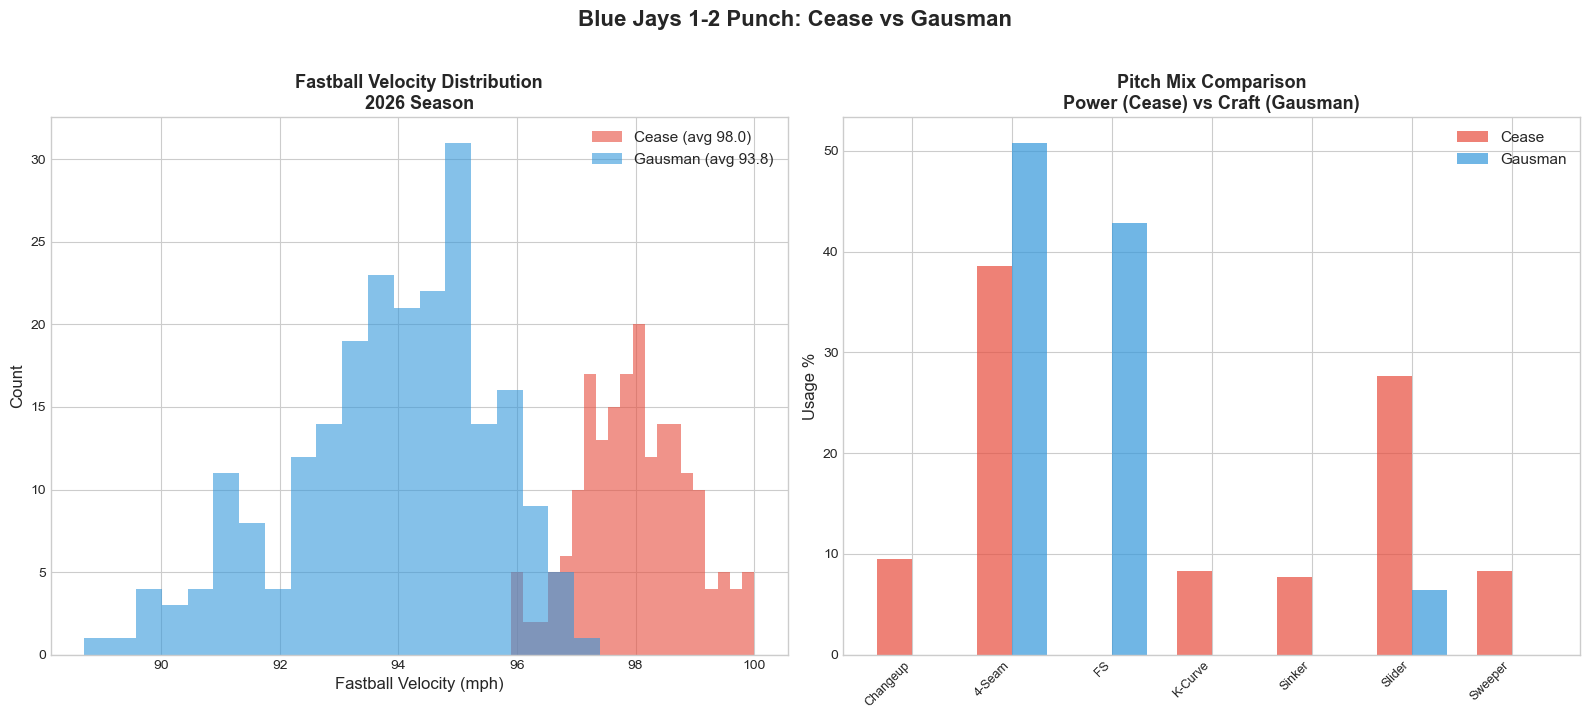

In [6]:
cease_2026 = pd.read_csv('../data/cease_2026.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Velocity distribution comparison
ax1 = axes[0]
cease_fb = cease_2026[cease_2026['pitch_type'] == 'FF']['release_speed'].dropna()
gausman_fb = gausman_2026[gausman_2026['pitch_type'] == 'FF']['release_speed'].dropna()

ax1.hist(cease_fb, bins=20, alpha=0.6, color='#e74c3c', label=f'Cease (avg {cease_fb.mean():.1f})')
ax1.hist(gausman_fb, bins=20, alpha=0.6, color='#3498db', label=f'Gausman (avg {gausman_fb.mean():.1f})')
ax1.set_xlabel('Fastball Velocity (mph)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Fastball Velocity Distribution\n2026 Season', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)

# Right: Pitch diversity comparison
ax2 = axes[1]
cease_mix = cease_2026['pitch_type'].value_counts(normalize=True) * 100
gausman_mix = gausman_2026['pitch_type'].value_counts(normalize=True) * 100

all_pitches = sorted(set(list(cease_mix.index) + list(gausman_mix.index)))
x = np.arange(len(all_pitches))
width = 0.35

cease_vals = [cease_mix.get(p, 0) for p in all_pitches]
gausman_vals = [gausman_mix.get(p, 0) for p in all_pitches]
labels = [pitch_labels.get(p, p) for p in all_pitches]

ax2.bar(x - width/2, cease_vals, width, color='#e74c3c', alpha=0.7, label='Cease')
ax2.bar(x + width/2, gausman_vals, width, color='#3498db', alpha=0.7, label='Gausman')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Usage %', fontsize=12)
ax2.set_title('Pitch Mix Comparison\nPower (Cease) vs Craft (Gausman)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

plt.suptitle("Blue Jays 1-2 Punch: Cease vs Gausman",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/08_cease_vs_gausman.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [7]:
gausman_2022.to_csv('../data/gausman_2022.csv', index=False)
gausman_2023.to_csv('../data/gausman_2023.csv', index=False)
gausman_2024.to_csv('../data/gausman_2024.csv', index=False)
print("Additional Gausman data saved!")

Additional Gausman data saved!
